In [5]:
!pip install -q grad-cam

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive, files
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("✅ Đã cài đặt và import thư viện thành công!")

✅ Đã cài đặt và import thư viện thành công!


In [7]:
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cpu")
print(f"Đang sử dụng thiết bị: {device}")

model_path = '/content/drive/MyDrive/Pneumonia Project/best_model_final.pth'

try:
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('state_dict', checkpoint)

    model = models.resnet18(weights=None)

    if 'fc.1.weight' in state_dict and 'fc.4.weight' in state_dict:
        fc1_out, fc1_in = state_dict['fc.1.weight'].shape
        fc4_out, fc4_in = state_dict['fc.4.weight'].shape
        model.fc = nn.Sequential(
            nn.Dropout(0.3),           # 0
            nn.Linear(fc1_in, fc1_out),# 1
            nn.ReLU(),                 # 2
            nn.Dropout(0.3),           # 3
            nn.Linear(fc4_in, fc4_out) # 4
        )
        is_binary = True
    elif 'fc.weight' in state_dict:
        fc_out, fc_in = state_dict['fc.weight'].shape
        model.fc = nn.Linear(fc_in, fc_out)
        is_binary = (fc_out == 1)

    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval() #

    threshold = checkpoint.get('threshold_f1', 0.5) if isinstance(checkpoint, dict) else 0.5

    print(f"✅ Tải mô hình thành công! (Binary mode: {is_binary})")
    print(f"   - Ngưỡng đánh giá (Threshold): {threshold}")

except Exception as e:
    print(f"❌ Lỗi khi tải mô hình: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang sử dụng thiết bị: cpu
✅ Tải mô hình thành công! (Binary mode: True)
   - Ngưỡng đánh giá (Threshold): 0.6054108738899231


📂 Vui lòng chọn 1 ảnh X-quang ngực gốc để chạy bộ lọc CLAHE:


Saving 1.jpeg to 1 (1).jpeg


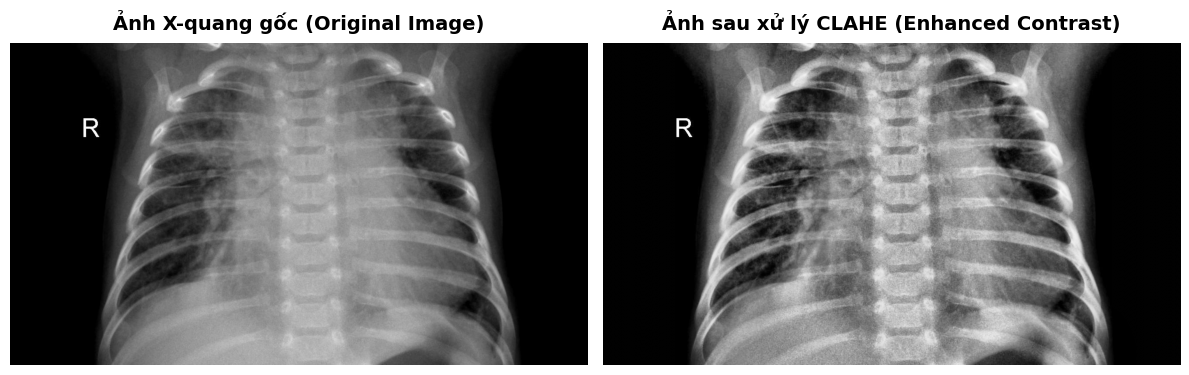


 THÀNH CÔNG! Đã xuất ảnh so sánh tại file: clahe_comparison.png


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# 1. Hiện nút bấm chọn ảnh từ máy tính của bạn để test
print("📂 Vui lòng chọn 1 ảnh X-quang ngực gốc để chạy bộ lọc CLAHE:")
uploaded = files.upload()
img_filename = list(uploaded.keys())[0]

# 2. Đọc ảnh gốc dưới dạng ảnh xám (Grayscale)
img_gray = cv2.imread(img_filename, cv2.IMREAD_GRAYSCALE)

# 3. Khởi tạo bộ lọc CLAHE (Giới hạn clipLimit=2.0 và ma trận cục bộ tileGridSize=8x8 giống lúc train)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

# 4. Trực quan hóa so sánh song song hai ảnh (Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Hiển thị ảnh gốc ban đầu
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Ảnh X-quang gốc (Original Image)", fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off') # Ẩn hệ trục tọa độ pixel

# Hiển thị ảnh sau khi qua bộ lọc CLAHE
axes[1].imshow(img_clahe, cmap='gray')
axes[1].set_title("Ảnh sau xử lý CLAHE (Enhanced Contrast)", fontsize=14, fontweight='bold', pad=10)
axes[1].axis('off') # Ẩn hệ trục tọa độ pixel

plt.tight_layout()

# 5. Lưu biểu đồ so sánh thành file ảnh chất lượng cao 300 DPI cho báo cáo
output_image_path = 'clahe_comparison.png'
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n THÀNH CÔNG! Đã xuất ảnh so sánh tại file: {output_image_path}")


📂 Vui lòng chọn 1 ảnh X-quang cần chẩn đoán:


Saving 3.jpg to 3.jpg


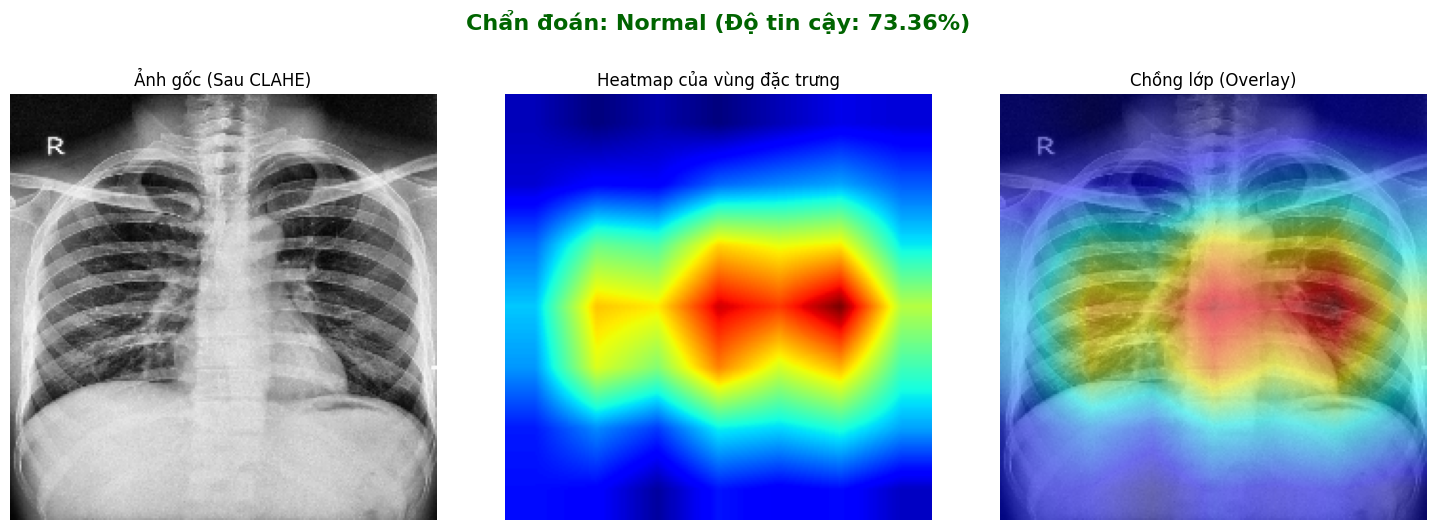

In [10]:
# 1. Hiện nút Upload ảnh
print("📂 Vui lòng chọn 1 ảnh X-quang cần chẩn đoán:")
uploaded = files.upload()
img_filename = list(uploaded.keys())[0]

# 2. Hàm Tiền xử lý
def preprocess_image(image_path, model_device):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    img_pil = Image.fromarray(img_rgb)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(img_pil).unsqueeze(0).to(model_device)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_for_plot = np.float32(img_resized) / 255
    return input_tensor, img_for_plot

current_device = next(model.parameters()).device
input_tensor, img_for_plot = preprocess_image(img_filename, current_device)

# 3. Dự đoán
with torch.no_grad():
    output = model(input_tensor)
    if is_binary:
        prob = torch.sigmoid(output).item()
        pred_idx = 1 if prob >= threshold else 0
        confidence = prob * 100 if pred_idx == 1 else (1 - prob) * 100
    else:
        probabilities = F.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probabilities)
        confidence = probabilities[pred_idx] * 100

    classes = ['Normal', 'Pneumonia']
    pred_class = classes[pred_idx]

# 4. TẠO CUSTOM TARGET ĐỂ SỬA LỖI GRAD-CAM CHO MÔ HÌNH NHỊ PHÂN
class BinaryClassifierOutputTarget:
    def __init__(self, category):
        self.category = category
    def __call__(self, model_output):
        if is_binary:
            # Nếu là Pneumonia (1), tính gradient trực tiếp.
            # Nếu là Normal (0), tính gradient đảo ngược.
            return model_output[0] if self.category == 1 else -model_output[0]
        else:
            return model_output[self.category]

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Yêu cầu Grad-CAM giải thích quyết định của class vừa dự đoán được
targets = [BinaryClassifierOutputTarget(pred_idx)]

# Tạo Heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
visualization = show_cam_on_image(img_for_plot, grayscale_cam, use_rgb=True)

# 5. In kết quả trực quan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Chẩn đoán: {pred_class} (Độ tin cậy: {confidence:.2f}%)",
             fontsize=16, fontweight='bold', y=1.05,
             color='darkred' if pred_class == 'Pneumonia' else 'darkgreen')

axes[0].imshow(img_for_plot)
axes[0].set_title("Ảnh gốc (Sau CLAHE)")
axes[0].axis('off')

axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title("Heatmap của vùng đặc trưng")
axes[1].axis('off')

axes[2].imshow(visualization)
axes[2].set_title("Chồng lớp (Overlay)")
axes[2].axis('off')

plt.tight_layout()
plt.show()